{
    'topic': '莲花',
    'content_type': 'poem',
    'content_Chinese': '一首诗',
    'poem': 
'好的，这是一首关于莲花的诗：\n\n**莲花赞**\n\n淤泥深处是家园，\n不争不抢，默默扎根。\n碧叶田田铺水面，\n绿伞撑开，
护佑清芬。\n\n夏日炎炎，骄阳似火，\n她却亭亭，不染尘浊。\n一茎独秀破水出，\n纤尘不染，风骨自若。\n\n粉黛轻施或素白
，\n花瓣层叠，心蕊含香。\n晨曦微露悄然绽，\n晚风轻拂暗送幽芳。\n\n不慕繁华，不染世嚣，\n清净无为，自在逍遥。\n她是
君子，品格高洁，\n出淤泥而不染，濯清涟而不妖。\n\n愿我心亦如莲花，\n历经风雨，纯净无瑕。\n在俗世中寻得一方净土，\n
绽放生命的光华，永恒优雅。'
}

==================================================

{
    'topic': '猫咪',
    'content_type': 'joke',
    'content_Chinese': '一个笑话',
    'joke': 
'好的，来一个关于猫咪的笑话：\n\n主人问他的猫咪：“你每天除了吃就是睡，到底有什么远大理想啊？”\n\n猫咪打了个哈欠，瞥
了主人一眼，懒洋洋地说：\n\n“我的远大理想就是……能教会你什么时候该给我加饭了！”'
}

{'topic': '猫咪', 'content_type': 'xxx'}

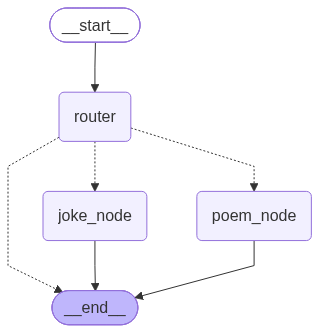

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	poem_node(poem_node)
	joke_node(joke_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	router -.-> __end__;
	router -.-> joke_node;
	router -.-> poem_node;
	joke_node --> __end__;
	poem_node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
"""
动态分支 - command 条件分支
"""

from typing import TypedDict,Literal, NotRequired
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langchain.chat_models import init_chat_model
from rich import print as rprint
import os
from dotenv import load_dotenv
load_dotenv(override=True)

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    content_type: Literal["poem","joke"]
    content_Chinese: NotRequired[str]
    poem: str
    joke: str

#2. 定义路由节点
def router(state:OverAllState) -> Command[Literal["poem_node","joke_node","__end__"]]:
    if state["content_type"] == "poem":
        return Command(
            update={
                "content_Chinese": "一首诗"
            },
            goto="poem_node"
        )
    elif state["content_type"] == "joke":
        return Command(
            update={
                "content_Chinese": "一个笑话"
            },
            goto="joke_node"
        )
    else:
        return Command(
            goto=END
        )

def poem_node(state:OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的{state['content_Chinese']}"]).content
    return {
        "poem": poem
    }


def joke_node(state:OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的{state['content_Chinese']}"]).content
    return {
        "joke": joke
    }

# 3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("router",router)
builder.add_node("poem_node",poem_node)
builder.add_node("joke_node",joke_node)

builder.add_edge(START,"router")
builder.add_edge("poem_node",END)
builder.add_edge("joke_node",END)

graph = builder.compile()

res1 = graph.invoke({"topic": "莲花","content_type": "poem"})
rprint(res1)

rprint("="*50)

res2 = graph.invoke({"topic": "猫咪","content_type": "joke"})
rprint(res2)

res3 = graph.invoke({"topic": "猫咪","content_type": "xxx"})
rprint(res3)

from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)
